In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [7]:
# Параметры системы
l1, l2 = 1.0, 0.15
m_true = np.array([5.0, 1.5, 0.5]) # Истинные массы [m1, m2, m3]
B_true = np.array([1.2, 0.8, 2.4]) # Истинные коэффициенты вязкого трения
D_true = np.array([0.6, 0.4, 1.1]) # Истинные коэффициенты сухого трения
g = 9.81
T_end = 2.0

In [22]:
# Целевая траектория
def get_target(t):
    c = [
        [np.pi/4, 0, 0, 25*np.pi/48, -25*np.pi/64, 5*np.pi/64],
        [0.1, 0, 0, 0.25, -0.1875, 0.0375],
        [np.pi/2, 0, 0, -5*np.pi/12, 5*np.pi/16, -np.pi/16]
    ]
    qd, dqd, ddqd = [], [], []
    for i in range(3):
        qd.append(c[i][0] + c[i][3]*t**3 + c[i][4]*t**4 + c[i][5]*t**5)
        dqd.append(3*c[i][3]*t**2 + 4*c[i][4]*t**3 + 5*c[i][5]*t**4)
        ddqd.append(6*c[i][3]*t + 12*c[i][4]*t**2 + 20*c[i][5]*t**3)
    return np.array(qd), np.array(dqd), np.array(ddqd)

# Прямая кинематика
def forward_kinematics(q):
    q1, q2, q3 = q
    x = -(l2 * np.cos(q3) + q2) * np.sin(q1)
    y = (l2 * np.cos(q3) + q2) * np.cos(q1)
    z = l1 + l2 * np.sin(q3)
    return x, y, z

# Динамика и Регрессор
def get_dynamics_matrices(q, dq, m, B_diag, D_diag):
    q2, q3 = q[1], q[2]
    dq1, dq2, dq3 = dq
    m2, m3 = m[1], m[2]

    M = np.zeros((3, 3))
    M[0, 0] = m2*q2**2 + m3*(q2 + l2*np.cos(q3))**2
    M[1, 1] = m2 + m3
    M[1, 2] = M[2, 1] = -m3*l2*np.sin(q3)
    M[2, 2] = m3*l2**2

    C_vec = np.array([
        2*(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1*dq2 - 2*m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1*dq3,
        -(m2*q2 + m3*(q2 + l2*np.cos(q3)))*dq1**2 - m3*l2*dq3**2*np.cos(q3),
        m3*l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1**2
    ])
    G_vec = np.array([0, 0, m3*g*l2*np.cos(q3)])
    Friction = B_diag * dq + D_diag * np.tanh(100 * dq)
    return M, C_vec, G_vec, Friction

def get_regressor(q, dq, dq_ref, ddq_ref):
    q2, q3 = q[1], q[2]
    dq1, dq2, dq3 = dq
    Y = np.zeros((3, 8)) # 8 параметров: m2, m3, B1-3, D1-3

    Y[0,0] = q2**2 * ddq_ref[0] + 2*q2*dq2*dq_ref[0]
    Y[1,0] = ddq_ref[1] - q2*dq1*dq_ref[0]

    Y[0,1] = (q2 + l2*np.cos(q3))**2 * ddq_ref[0] + 2*(q2 + l2*np.cos(q3))*(dq2 - l2*np.sin(q3)*dq3)*dq_ref[0]
    Y[1,1] = ddq_ref[1] - l2*np.sin(q3)*ddq_ref[2] - (q2 + l2*np.cos(q3))*dq1*dq_ref[0] - l2*np.cos(q3)*dq3*dq_ref[2]
    Y[2,1] = -l2*np.sin(q3)*ddq_ref[1] + l2**2*ddq_ref[2] + l2*(q2 + l2*np.cos(q3))*np.sin(q3)*dq1*dq_ref[0] + g*l2*np.cos(q3)

    for i in range(3):
        Y[i, 2+i] = dq[i]
        Y[i, 5+i] = np.tanh(100 * dq[i])
    return Y

# Уравнения состояния системы
def robot_ode(t, state, method):
    q, dq = state[0:3], state[3:6]
    theta_hat = state[6:14]

    qd, dqd, ddqd = get_target(t)
    e, de = qd - q, dqd - dq

    if method == 'lyapunov':
        Lambda, Ks = np.diag([10, 10, 10]), np.diag([50, 50, 50])
        s = de + Lambda @ e
        dqr, ddqr = dqd + Lambda @ e, ddqd + Lambda @ de
        Y = get_regressor(q, dq, dqr, ddqr)
        tau = Y @ theta_hat + Ks @ s
        Gamma = np.diag([2.0, 2.0, 5.0, 5.0, 5.0, 2.0, 2.0, 2.0])
        d_theta_hat = Gamma @ Y.T @ s

    elif method == 'inverse':
        Kp, Kv = np.diag([100, 100, 100]), np.diag([20, 20, 20])
        aq = ddqd + Kv @ de + Kp @ e
        Y = get_regressor(q, dq, dq, aq)
        tau = Y @ theta_hat
        Gamma = np.diag([1.0, 1.0, 2.0, 2.0, 2.0, 1.0, 1.0, 1.0])
        d_theta_hat = Gamma @ Y.T @ de

    M, C, G, F = get_dynamics_matrices(q, dq, m_true, B_true, D_true)
    ddq = np.linalg.solve(M, tau - C - G - F)
    return np.concatenate((dq, ddq, d_theta_hat))

In [12]:
# построения всех графиков
def plot_results(sol, title_prefix):
    t = sol.t
    q = sol.y[0:3]
    dq = sol.y[3:6]
    theta = sol.y[6:14]

    x, y, z = np.zeros_like(t), np.zeros_like(t), np.zeros_like(t)
    for i in range(len(t)):
        x[i], y[i], z[i] = forward_kinematics(q[:, i])

    fig = plt.figure(figsize=(20, 15))
    fig.suptitle(f'Результаты моделирования: {title_prefix}', fontsize=16, fontweight='bold')

    # R1: Обобщенные координаты
    ax1 = fig.add_subplot(3, 2, 1)
    ax1.plot(t, q[0], label='$q_1(t)$'); ax1.plot(t, q[1], label='$q_2(t)$'); ax1.plot(t, q[2], label='$q_3(t)$')
    ax1.set_title('R1: Обобщенные координаты')
    ax1.legend(); ax1.grid()

    # R2: Скорости
    ax2 = fig.add_subplot(3, 2, 2)
    ax2.plot(t, dq[0], label=r'$\dot{q}_1(t)$')
    ax2.plot(t, dq[1], label=r'$\dot{q}_2(t)$')
    ax2.plot(t, dq[2], label=r'$\dot{q}_3(t)$')
    ax2.set_title('R2: Скорости звеньев')
    ax2.legend(); ax2.grid()

    # R3: Декартовы координаты
    ax3 = fig.add_subplot(3, 2, 3)
    ax3.plot(t, x, label='x(t)')
    ax3.plot(t, y, label='y(t)')
    ax3.plot(t, z, label='z(t)')
    ax3.set_title('R3: Декартовы координаты')
    ax3.legend(); ax3.grid()

    # R4: 3D траектория z(x,y)
    ax4 = fig.add_subplot(3, 2, 4, projection='3d')
    ax4.plot(x, y, z, color='black', lw=2)
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')
    ax4.set_title('R4: Общая траектория $z=z(x,y)$')

    # R5: Оценка масс
    ax5 = fig.add_subplot(3, 2, 5)
    ax5.plot(t, np.full_like(t, m_true[0]), 'r--', label=r'$\hat{m}_1$ (const)') # m1 не влияет на динамику схвата
    ax5.plot(t, theta[0], 'g', label=r'$\hat{m}_2$')
    ax5.plot(t, theta[1], 'b', label=r'$\hat{m}_3$')
    ax5.axhline(m_true[1], color='g', linestyle=':', alpha=0.5)
    ax5.axhline(m_true[2], color='b', linestyle=':', alpha=0.5)
    ax5.set_title(r'R5: Оценка масс $\hat{m}_i(t)$')
    ax5.legend(); ax5.grid()

    # R5: Оценка коэффициентов трения
    ax6 = fig.add_subplot(3, 2, 6)
    ax6.plot(t, theta[2:5].T, '--', label=[r'$\hat{B}_1$', r'$\hat{B}_2$', r'$\hat{B}_3$'])
    ax6.plot(t, theta[5:8].T, ':', label=[r'$\hat{D}_1$', r'$\hat{D}_2$', r'$\hat{D}_3$'])
    ax6.set_title(r'R5: Оценка коэффициентов трения $\hat{B}(t), \hat{D}(t)$')
    ax6.legend(ncol=2); ax6.grid()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [13]:
# Задаем ошибочные начальные оценки параметров (например, отклонение 50%)
initial_theta = np.array([m_true[1]*0.5, m_true[2]*0.5, 0.5, 0.5, 1.0, 0.2, 0.2, 0.5])
y0 = np.concatenate(([np.pi/4, 0.1, np.pi/2], [0,0,0], initial_theta))

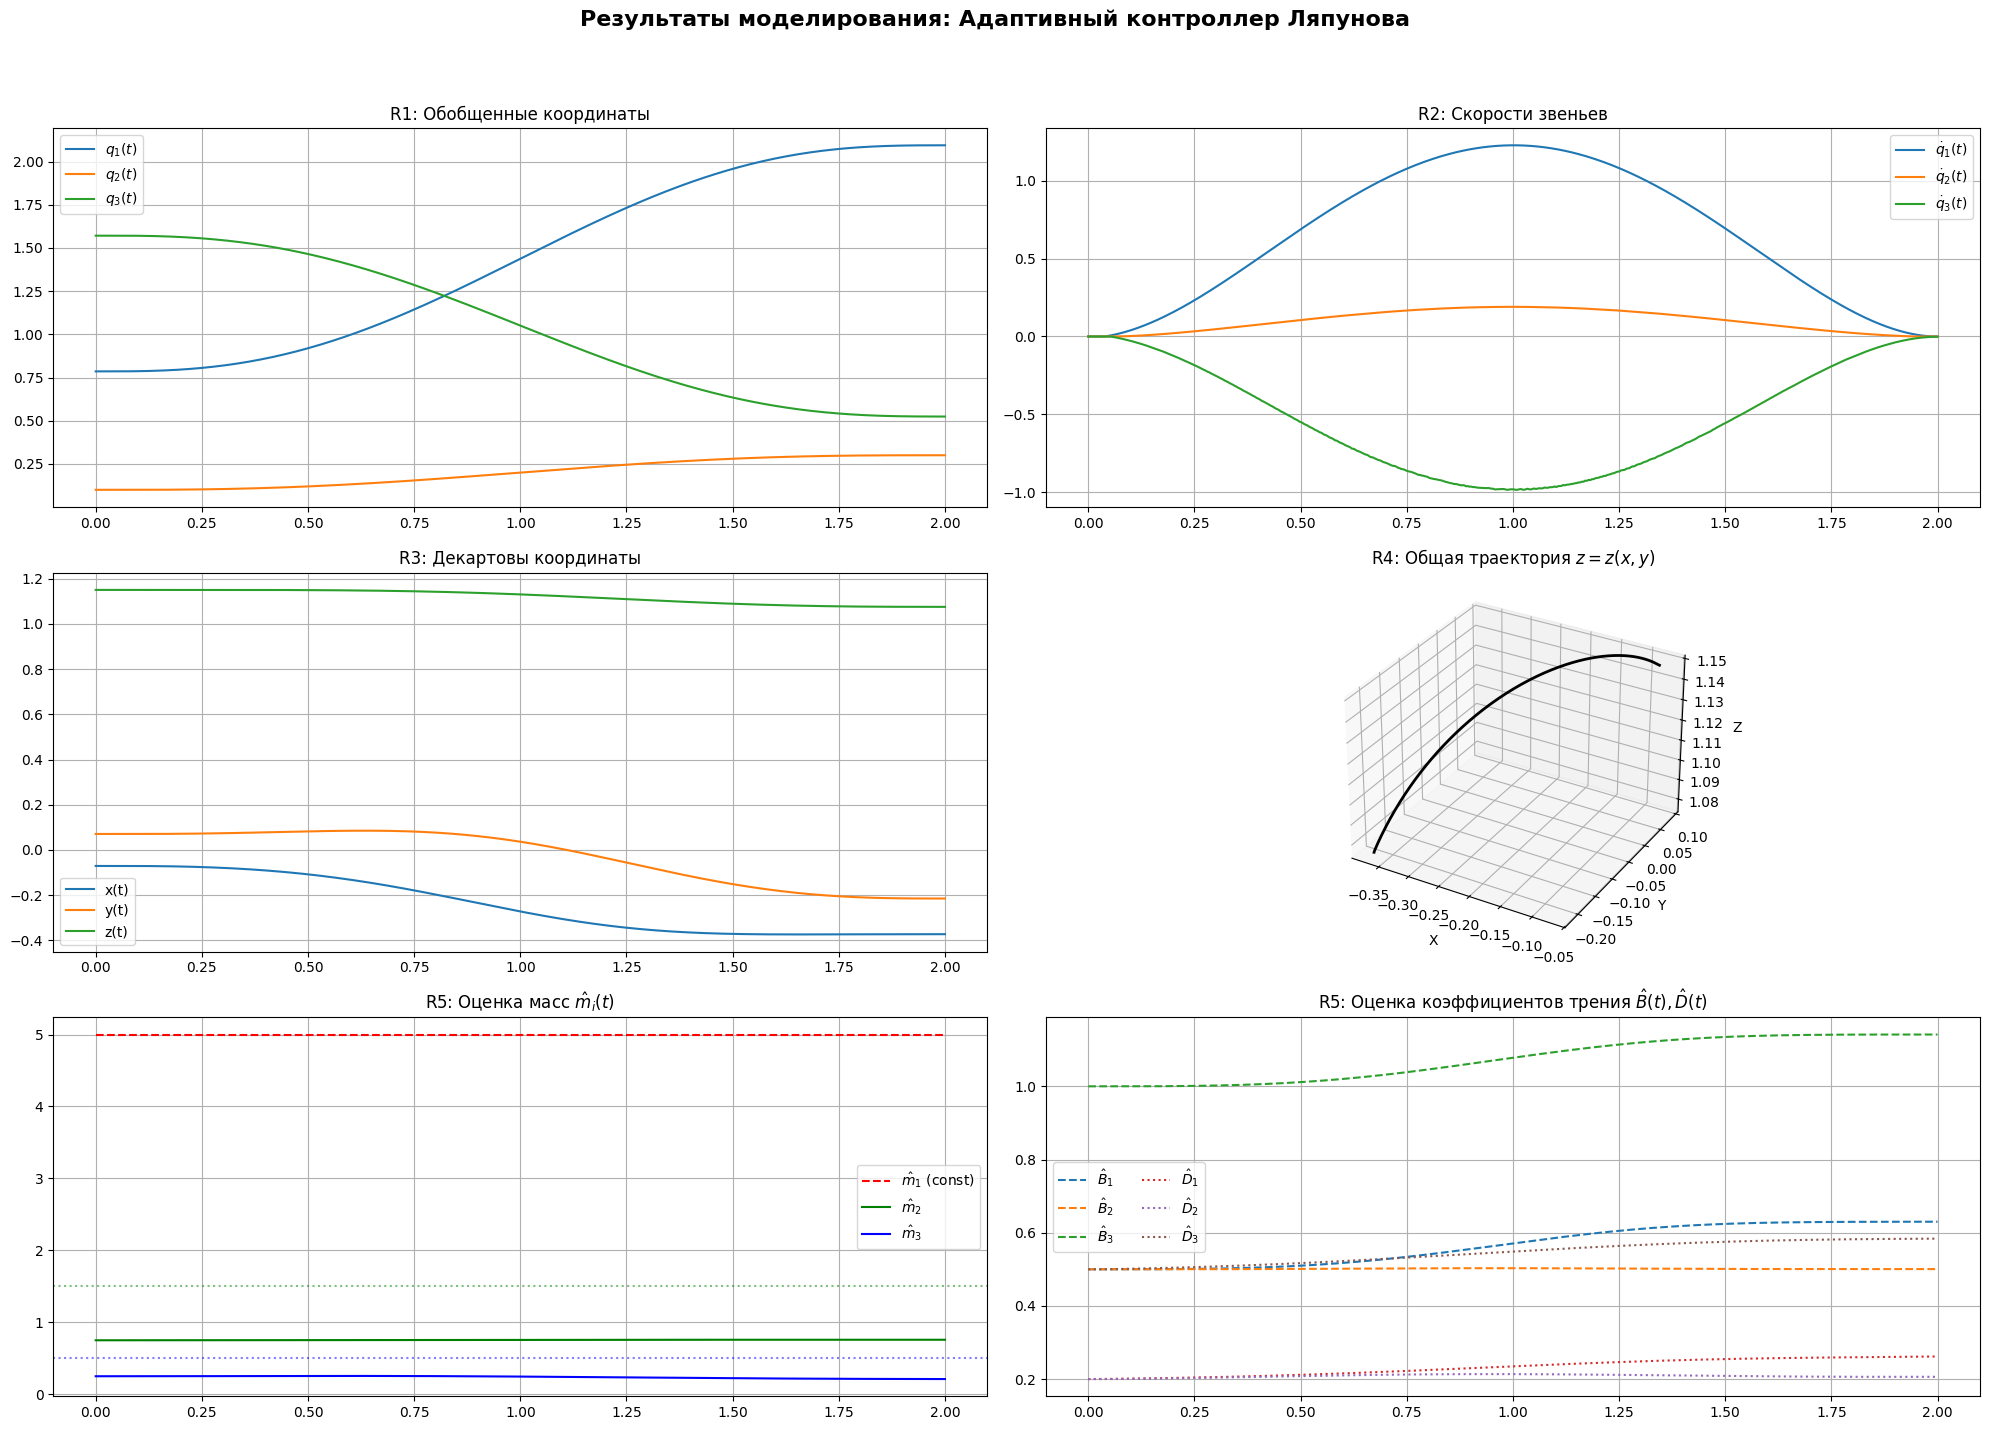

In [17]:
# Запуск метода Ляпунова
sol_lya = solve_ivp(robot_ode, [0, T_end], y0, args=('lyapunov',), t_eval=np.linspace(0, T_end, 500))
plot_results(sol_lya, "Адаптивный контроллер Ляпунова")

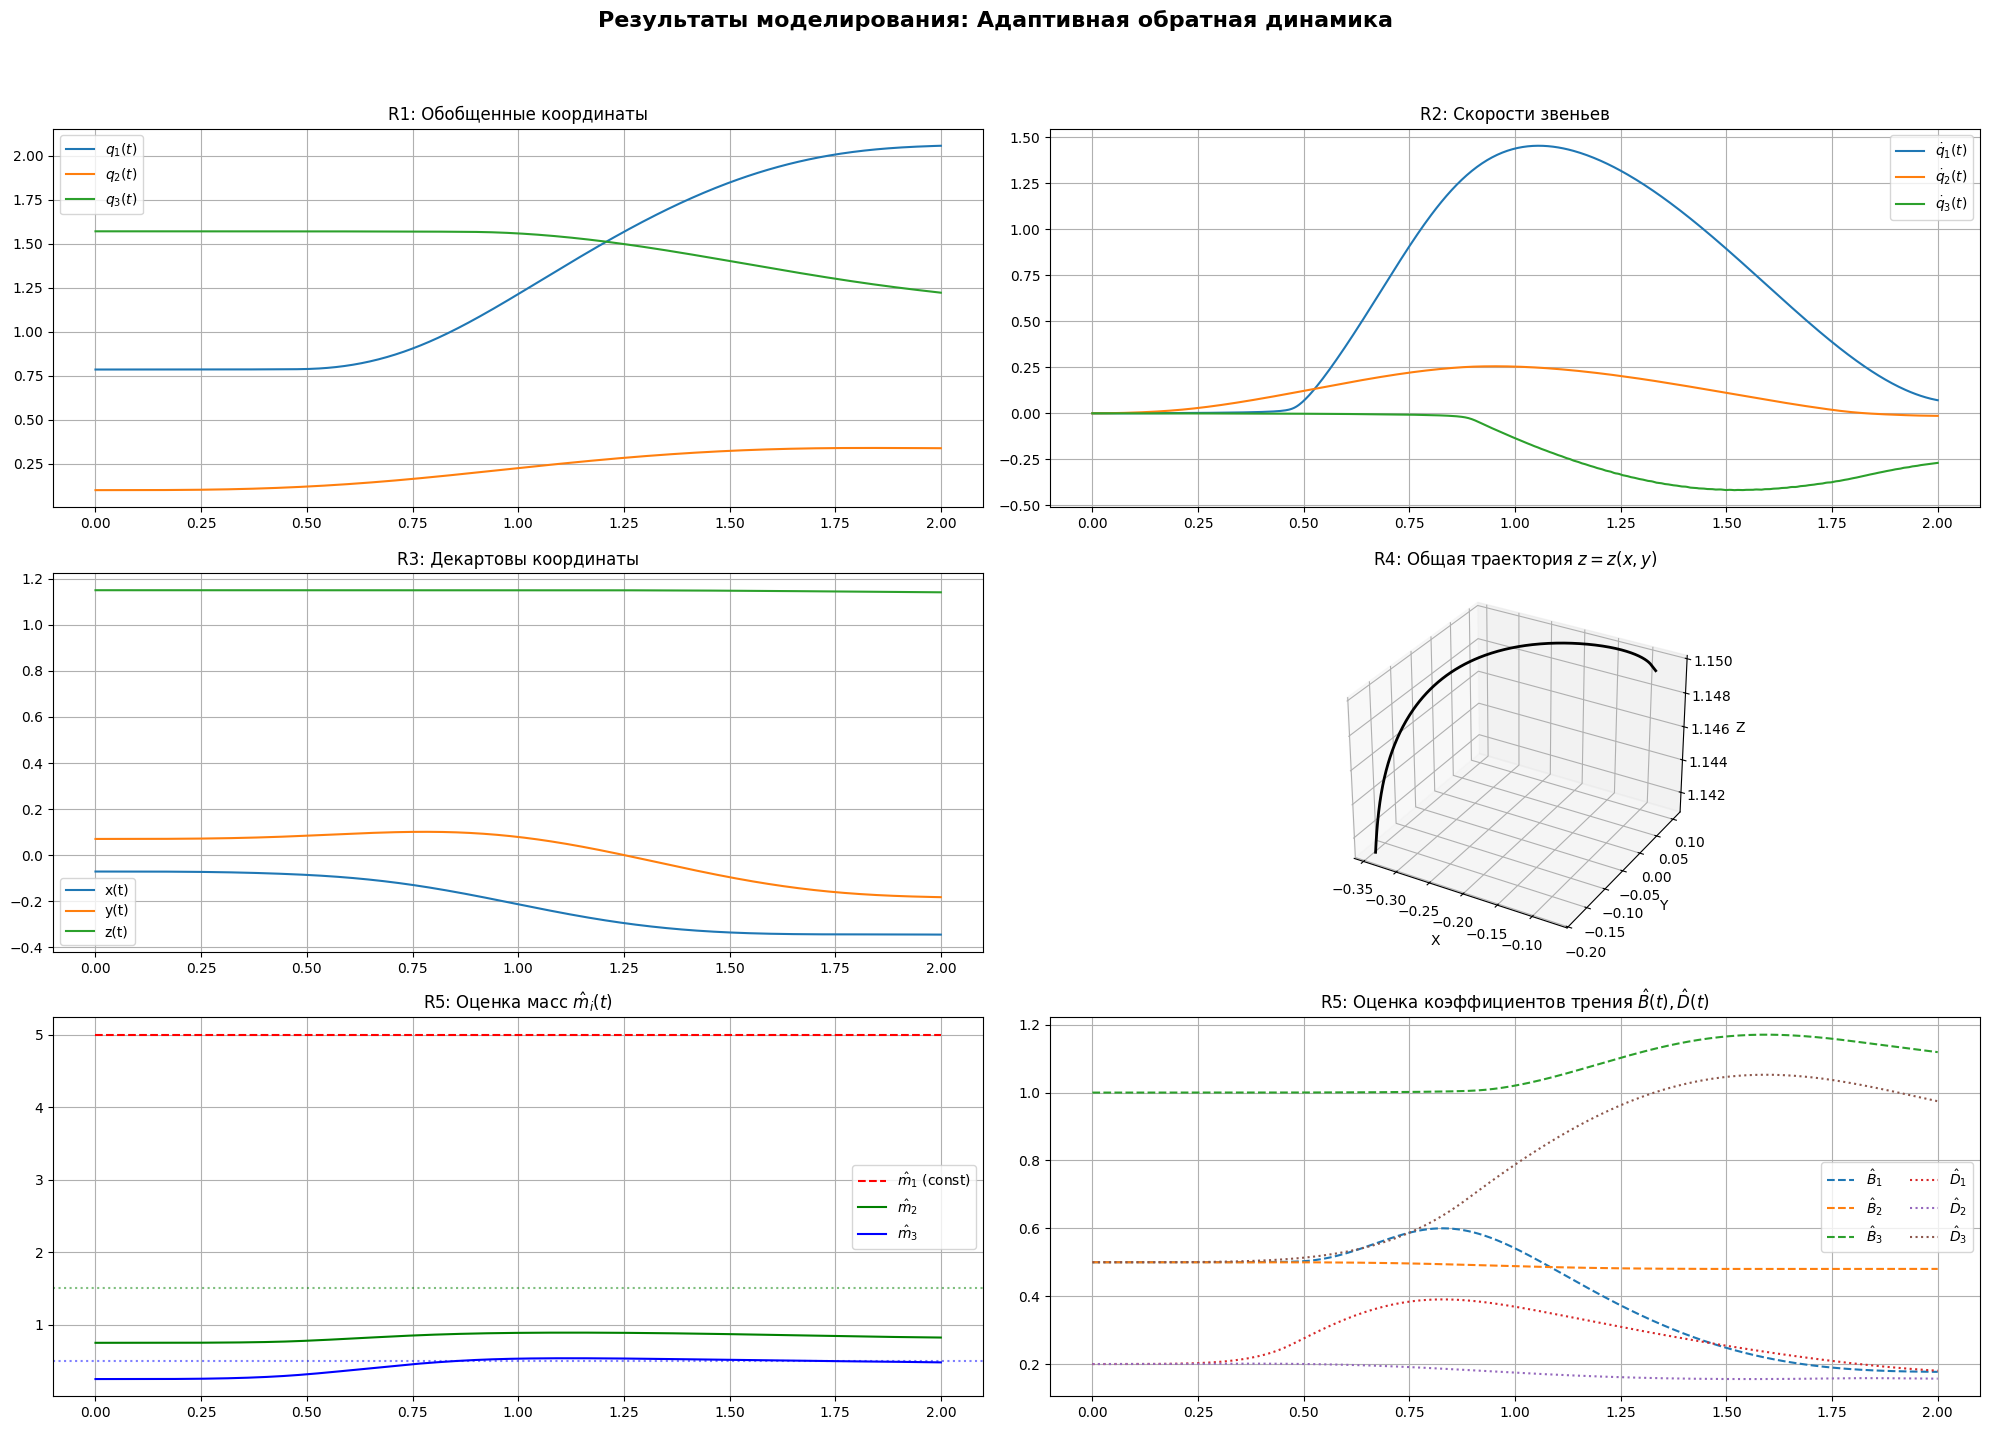

In [23]:
# Запуск метода Обратной динамики
sol_inv = solve_ivp(robot_ode, [0, T_end], y0, args=('inverse',), t_eval=np.linspace(0, T_end, 500))
plot_results(sol_inv, "Адаптивная обратная динамика")